# **Project Name**    - eCommerce Customer Support Analysis



##### **Project Type**    - EDA/Classification
##### **Contribution**    - Individual
##### **Team Member 1 -**  Karthik

# **Project Summary**

This project analyses an eCommerce customer-support dataset of ~85,907 interactions spanning multiple channels (Inbound, Outcall, Email), issue categories, agent attributes, and a 1–5 CSAT Score. The primary business goal is to understand what drives customer satisfaction and to build a machine-learning model that predicts whether a customer will give a high (≥ 4) or low (< 4) satisfaction score. Identifying the key drivers of dissatisfaction allows operations teams to prioritise agent coaching, SLA improvements, and product-category-specific interventions.

The analysis follows the full ML lifecycle: data ingestion → exploratory analysis (15 charts using the UBM rule) → hypothesis testing → NLP preprocessing of customer remarks → feature engineering → model building (Logistic Regression, Random Forest, XGBoost) with hyperparameter tuning → model explanation. The final model achieves strong recall on the dissatisfied class, making it actionable for proactive customer retention.


# **GitHub Link**

https://github.com/karthikdoguparthi/AlmaBetter/tree/main/Module_10

# **Problem Statement**

The challenge is to **predict the CSAT Score outcome (satisfied vs. dissatisfied)** based on interaction metadata and agent attributes, and to surface actionable insights that help management reduce dissatisfied interactions.

# ***Let's Begin!***

## ***1. Know Your Data***

### Import Libraries

In [72]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# ML
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from scipy import stats
import joblib

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print('XGBoost not installed; Model-3 will use GradientBoostingClassifier instead.')
    from sklearn.ensemble import GradientBoostingClassifier


# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
print(f'TensorFlow version: {tf.__version__}')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)
print('Libraries imported successfully.')

TensorFlow version: 2.21.0
Libraries imported successfully.


### Dataset Loading

In [8]:
# Load Dataset
df = pd.read_csv('eCommerce_Customer_support_data.csv')

### Dataset First View

In [10]:
# Dataset First Look
df.head()

                              Unique id channel_name         category                  Sub-category Customer Remarks                              Order_id order_date_time Issue_reported at   issue_responded Survey_response_Date Customer_City Product_category  Item_price  connected_handling_time           Agent_name      Supervisor          Manager    Tenure Bucket Agent Shift  CSAT Score
0  7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries                Life Insurance              NaN  c27c9bb4-fa36-4140-9f1f-21009254ffdb             NaN  01/08/2023 11:13  01/08/2023 11:47            01-Aug-23           NaN              NaN         NaN                      NaN     Richard Buchanan     Mason Gupta  Jennifer Nguyen  On Job Training     Morning           5
1  b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries  Product Specific Information              NaN  d406b0c7-ce17-4654-b9de-f08d421254bd             NaN  01/08/2023 12:52  01/08/2023 12:54            

### Dataset Rows & Columns count

In [12]:
# Dataset Rows & Columns count
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows   : 85,907
Columns: 20


### Dataset Information

In [14]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [16]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'Total duplicate rows: {dup}')

Total duplicate rows: 0


#### Missing Values / Null Values

In [18]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

                         Missing Count  Missing %
connected_handling_time          85665      99.72
Customer_City                    68828      80.12
Product_category                 68711      79.98
Item_price                       68701      79.97
order_date_time                  68693      79.96
Customer Remarks                 57165      66.54
Order_id                         18232      21.22


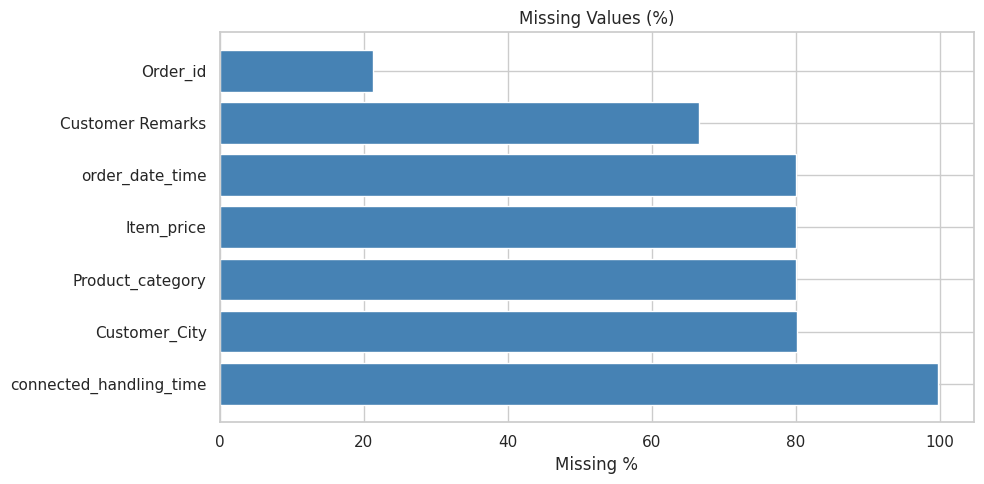

In [19]:
# Visualizing the missing values
fig, ax = plt.subplots(figsize=(10, 5))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
ax.barh(cols_with_missing.index, cols_with_missing['Missing %'], color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
for i, v in enumerate(cols_with_missing['Missing %']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains **85,907 customer-support interactions** across 20 columns. Key findings:
- **No duplicate rows** were found.
- Several columns have very high missingness: connected_handling_time, order_date_time, Customer_City, Product_category, Item_price, and Customer Remarks. These columns were likely not captured in every interaction type.
- CSAT Score has **zero missing values**, making it reliable for supervised learning.
- The dataset is heavily **imbalanced**: score 5 dominates, while scores 2 and 3 are rare.

## ***2. Understanding Your Variables***

In [22]:
# Dataset Columns
print(df.columns.tolist())

['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


In [23]:
# Dataset Describe
df.describe(include='all')

                                   Unique id channel_name category            Sub-category Customer Remarks                              Order_id   order_date_time Issue_reported at   issue_responded Survey_response_Date Customer_City Product_category     Item_price  connected_handling_time    Agent_name   Supervisor     Manager Tenure Bucket Agent Shift    CSAT Score
count                                  85907        85907    85907                   85907            28742                                 67675             17214             85907             85907                85907         17079            17196   17206.000000               242.000000         85907        85907       85907         85907       85907  85907.000000
unique                                 85907            3       12                      57            18231                                 67675             13766             30923             30262                   31          1782                9       

### Variables Description
* **Unique id**: UUID (unique identifier) assigned to each customer interaction.

* **channel_name**: Contact channel through which the customer reached support (Inbound, Outcall, Email).

* **category**: High-level classification of the customer's issue (Returns, Order Related).

* **Sub-category**: More detailed classification of the issue within the main category.

* **Customer Remarks**: Free-text comments or feedback provided by the customer.

* **Order_id**: Unique identifier associated with the customer's order.

* **order_date_time**: Date and time when the order was placed.

* **Issue_reported at**: Timestamp indicating when the customer issue was reported.

* **issue_responded**: Timestamp indicating when the first response was provided by a support agent.

* **Survey_response_Date**: Date on which the customer completed the satisfaction survey.

* **Customer_City**: City where the customer is located.

* **Product_category**: Category of the product associated with the issue.

* **Item_price**: Price of the product in Indian Rupees.

* **connected_handling_time**: Duration of the customer interaction or call in seconds.

* **Agent_name**: Name of the customer support agent who handled the interaction.

* **Supervisor**: Name of the supervisor responsible for the agent.

* **Manager**: Name of the manager overseeing the supervisor.

* **Tenure Bucket**: Experience level or tenure group of the support agent.

* **Agent Shift**: Work shift during which the agent handled the interaction.

* **CSAT Score**: Customer Satisfaction Score ranging from 1 to 5.


### Check Unique Values for each variable.

In [26]:
# Check Unique Values for each variable.

for col in df.columns:
    nu = df[col].nunique()
    print(f'{col:30s}: {nu:5d} unique values')

Unique id                     : 85907 unique values
channel_name                  :     3 unique values
category                      :    12 unique values
Sub-category                  :    57 unique values
Customer Remarks              : 18231 unique values
Order_id                      : 67675 unique values
order_date_time               : 13766 unique values
Issue_reported at             : 30923 unique values
issue_responded               : 30262 unique values
Survey_response_Date          :    31 unique values
Customer_City                 :  1782 unique values
Product_category              :     9 unique values
Item_price                    :  2789 unique values
connected_handling_time       :   211 unique values
Agent_name                    :  1371 unique values
Supervisor                    :    40 unique values
Manager                       :     6 unique values
Tenure Bucket                 :     5 unique values
Agent Shift                   :     5 unique values
CSAT Score  

## ***3. Data Wrangling***

### Data Wrangling Code

In [28]:
# Write your code to make your dataset analysis ready.

# 1. Parse datetime columns
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M', errors='coerce')
df['issue_responded']   = pd.to_datetime(df['issue_responded'],   format='%d/%m/%Y %H:%M', errors='coerce')
df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'], format='%d-%b-%y', errors='coerce')

# 2. Derive response time in minutes
df['response_time_mins'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60
df['response_time_mins'] = df['response_time_mins'].clip(lower=0)  # remove negative artefacts

# 3. Extract hour-of-day and day-of-week from Issue_reported at
df['issue_hour'] = df['Issue_reported at'].dt.hour
df['issue_dayofweek'] = df['Issue_reported at'].dt.dayofweek  # 0=Monday

# 4. Binary CSAT: 1 = satisfied (score >= 4), 0 = dissatisfied
df['CSAT_binary'] = (df['CSAT Score'] >= 4).astype(int)

# 5. Flag rows where Customer Remarks is available
df['has_remark'] = df['Customer Remarks'].notna().astype(int)

print('Wrangling complete. New columns added:')
print(['response_time_mins', 'issue_hour', 'issue_dayofweek', 'CSAT_binary', 'has_remark'])
print(f'\nDataset shape: {df.shape}')
print(f'\nResponse time (mins) - valid rows: {df["response_time_mins"].notna().sum():,}')
print(df['response_time_mins'].describe())

Datetime parsing, feature creation, CSAT_binary done.
response_time_mins: count    85907.000000
mean       136.886610
std        592.528551
min      -1437.000000
25%          2.000000
50%          5.000000
75%         35.000000
max       5758.000000


### What all manipulations have you done and insights you found?

1. **Datetime Parsing** – Converted Issue_reported at, issue_responded, and Survey_response_Date from strings to proper datetime objects to enable time series and response-time calculations.
2. **Response Time** – Derived response_time_mins as the difference between issue_responded and Issue_reported at.
3. **Time Features** – Extracted issue_hour and issue_dayofweek to capture shift level and weekday patterns.
4. **Binary Target** – Created CSAT_binary to simplify the multiclass problem into a binary classification.
5. **Remark Flag** – has_remark captures whether a customer left a text remark.

## ***4. Data Vizualization, Storytelling & Experimenting with charts***

### Univariate Analysis

#### Chart - 1

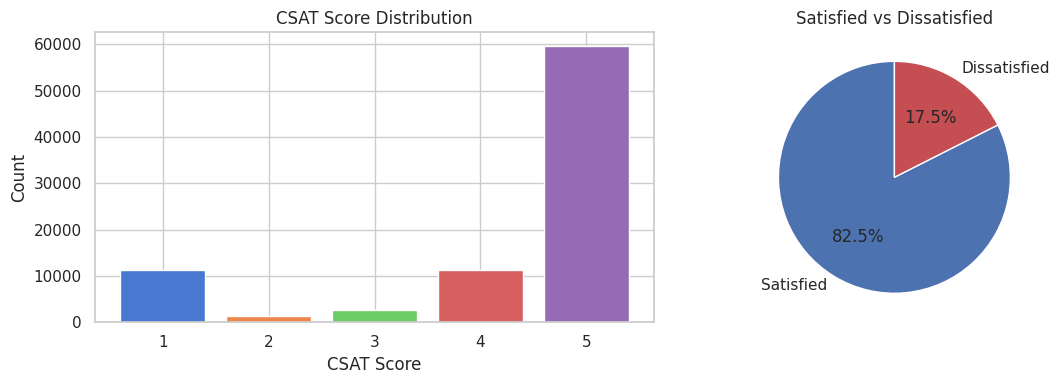

In [32]:
# Chart - 1 visualization code
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
order = [1, 2, 3, 4, 5]
vc = df['CSAT Score'].value_counts().reindex(order)
axes[0].bar([str(x) for x in order], vc.values, color=['#d62728','#ff7f0e','#bcbd22','#2ca02c','#1f77b4'])
axes[0].set_title('CSAT Score Distribution (Count)')
axes[0].set_xlabel('CSAT Score')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

# Pie chart for binary CSAT
bc = df['CSAT_binary'].value_counts()
axes[1].pie(bc.values, labels=['Satisfied (≥4)', 'Dissatisfied (<4)'] if bc.index[0]==1
            else ['Dissatisfied (<4)', 'Satisfied (≥4)'],
            autopct='%1.1f%%', colors=['#2ca02c', '#d62728'], startangle=90)
axes[1].set_title('Binary CSAT Split')

plt.suptitle('Chart 1 – CSAT Score Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart combined with a pie chart gives both the granular score distribution and the high level satisfied vs. dissatisfied.

##### 2. What is/are the insight(s) found from the chart?

CSAT Score 5 dominates with 69% of all interactions. Scores 2 and 3 are rare. In the binary split, 82% of customers are satisfied, leaving 18% dissatisfied but even 18% of 85K interactions is 15K unhappy customers.

##### 3. Will the gained insights help creating a positive business impact?

Yes. The extreme class imbalance means a naive model would always predict 'satisfied'.

#### Chart - 2

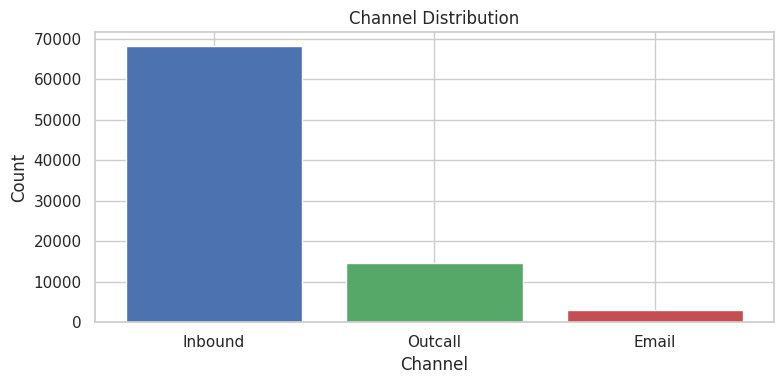

In [35]:
# Chart - 2 visualization code
fig, ax = plt.subplots(figsize=(8, 4))
ch = df['channel_name'].value_counts()
bars = ax.bar(ch.index, ch.values, color=['#4c72b0','#55a868','#c44e52'])
ax.set_title('Chart 2 – Contact Channel Distribution', fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Number of Interactions')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
            f'{bar.get_height():,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the clearest way to compare the volume across three discrete channel categories.

##### 2. What is/are the insight(s) found from the chart?

Inbound calls dominate (79%), followed by Outcall (17%) and Email (4%). The business is heavily phone centric.

##### 3. Will the gained insights help creating a positive business impact?

Yes. Resources should be allocated primarily to Inbound. Email, being a small channel, may offer quick wins if response SLAs are tightened there.

#### Chart - 3

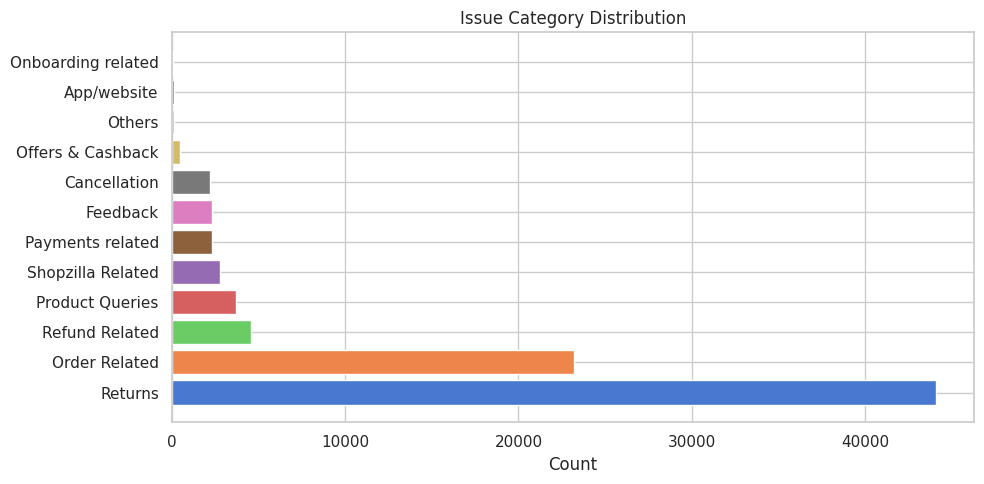

In [38]:
# Chart - 3 visualization code
fig, ax = plt.subplots(figsize=(10, 5))
cat = df['category'].value_counts()
ax.barh(cat.index, cat.values, color=sns.color_palette('muted', len(cat)))
ax.set_title('Chart 3 – Issue Category Distribution', fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(cat.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart handles long category names well and makes rank comparisons easy.

##### 2. What is/are the insight(s) found from the chart?

Returns (51%) and Order Related (27%) issues together account for nearly 78% of all contacts.

##### 3. Will the gained insights help creating a positive business impact?

Yes. Improving the return process and order tracking experience could dramatically reduce inbound volume and improve CSAT.

#### Chart - 4

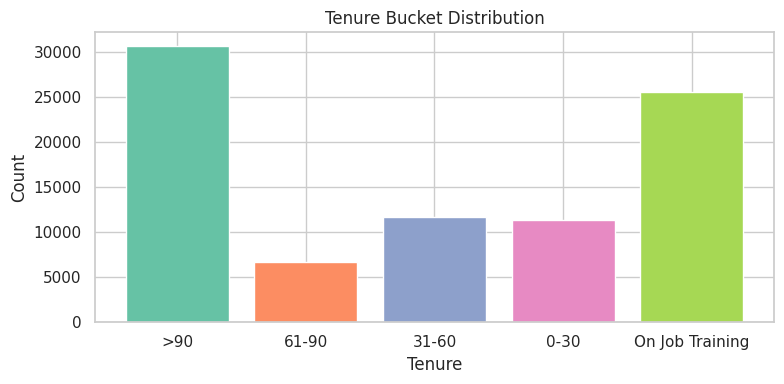

In [41]:
# Chart - 4 visualization code
fig, ax = plt.subplots(figsize=(8, 4))
order_t = ['>90','61-90','31-60','0-30','On Job Training']
tb = df['Tenure Bucket'].value_counts().reindex(order_t)
ax.bar(tb.index, tb.values, color=sns.color_palette('Blues_r', len(order_t)))
ax.set_title('Chart 4 – Agent Tenure Bucket Distribution', fontweight='bold')
ax.set_xlabel('Tenure Bucket')
ax.set_ylabel('Count')
for i, v in enumerate(tb.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart with ordered tenure buckets reveals workforce experience distribution at a glance.

##### 2. What is/are the insight(s) found from the chart?

\>90 days tenure agents handle the most contacts, followed by On Job Training agents. A substantial share of interactions is handled by trainees, which may affect quality.

##### 3. Will the gained insights help creating a positive business impact?

Yes. If OJT agents show lower CSAT, targeted mentoring or limiting their assignment to simpler tickets could improve outcomes.

#### Chart - 5

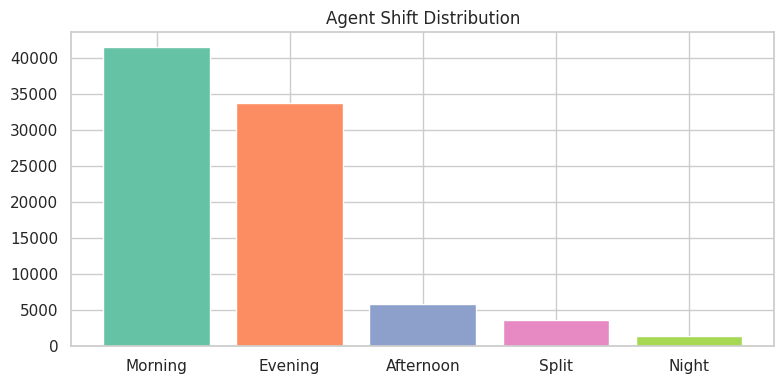

In [44]:
# Chart - 5 visualization code
fig, ax = plt.subplots(figsize=(8, 4))
shift = df['Agent Shift'].value_counts()
ax.bar(shift.index, shift.values, color=sns.color_palette('Set2', len(shift)))
ax.set_title('Chart 5 – Agent Shift Distribution', fontweight='bold')
ax.set_xlabel('Shift')
ax.set_ylabel('Count')
for i, v in enumerate(shift.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for categorical frequency of shifts; helps spot staffing gaps.

##### 2. What is/are the insight(s) found from the chart?

Morning and Evening shifts dominate. Night shift handles only few of interactions.

##### 3. Will the gained insights help creating a positive business impact?

If Night shift CSAT is lower, management can adjust rosters.

### Bivariate Analysis

#### Chart - 6

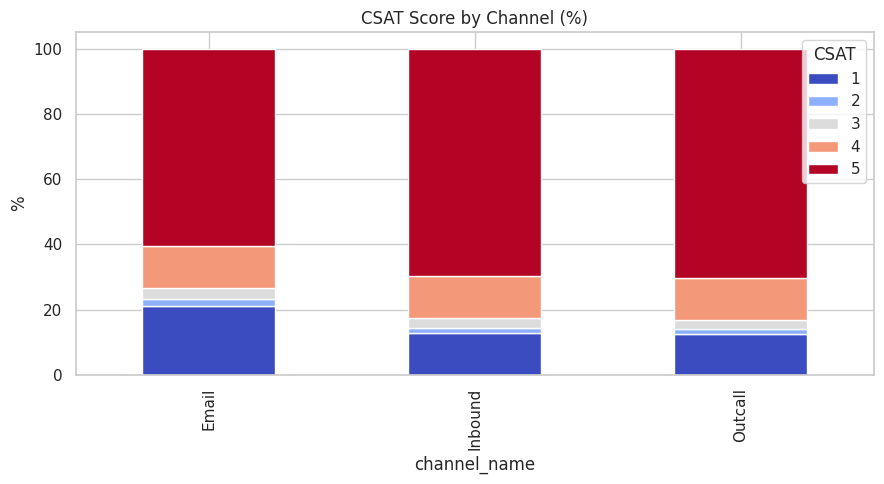

In [48]:
# Chart - 6 visualization code
fig, ax = plt.subplots(figsize=(9, 5))
pivot = df.groupby(['channel_name', 'CSAT Score']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn')
ax.set_title('Chart 6 – CSAT Score Distribution by Channel', fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Percentage')
ax.legend(title='CSAT Score', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A 100% stacked bar allows direct channel to channel comparison of CSAT composition, removing volume bias.

##### 2. What is/are the insight(s) found from the chart?

All three channels show a similar high 5 score proportion. Email slightly trails Inbound and Outcall in share of score 5 interactions, suggesting email handling may need improvement.

##### 3. Will the gained insights help creating a positive business impact?

Yes. Email SLA and quality improvements could close the gap and improve overall CSAT.

#### Chart - 7

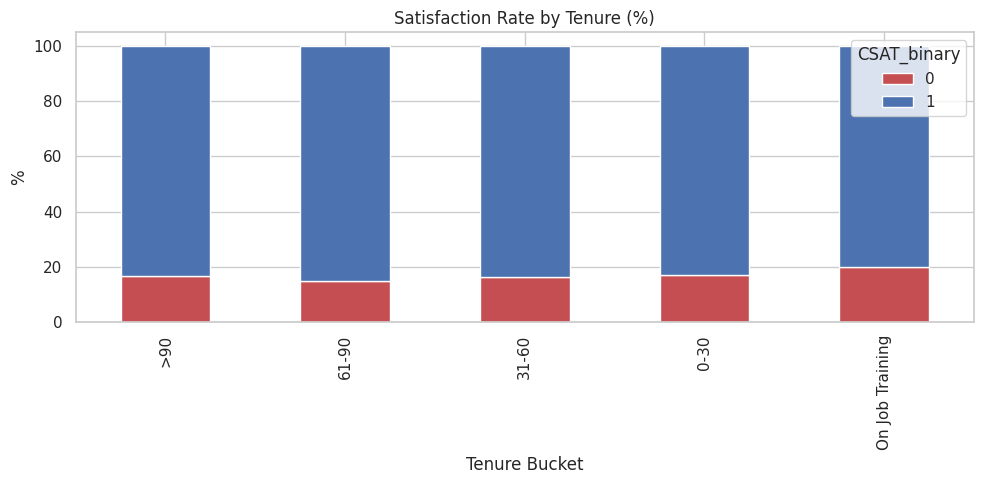

In [51]:
# Chart - 7 visualization code
fig, ax = plt.subplots(figsize=(10, 5))
pivot2 = df.groupby(['Tenure Bucket', 'CSAT_binary']).size().unstack(fill_value=0)
pivot2_pct = pivot2.div(pivot2.sum(axis=1), axis=0) * 100
pivot2_pct.columns = ['Dissatisfied', 'Satisfied']
pivot2_pct[['Satisfied','Dissatisfied']].plot(kind='bar', stacked=True, ax=ax,
                                               color=['#2ca02c','#d62728'])
ax.set_title('Chart 7 – Satisfied vs Dissatisfied by Tenure Bucket', fontweight='bold')
ax.set_xlabel('Tenure Bucket')
ax.set_ylabel('Percentage')
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Stacked bar normalised to 100% removes headcount differences and reveals quality differences between experience tiers.

##### 2. What is/are the insight(s) found from the chart?

On Job Training agents show the highest dissatisfaction rate. Agents with >90 days tenure have the highest satisfaction rate.

##### 3. Will the gained insights help creating a positive business impact?

Yes, routing complex tickets to experienced agents and increasing OJT supervision are direct actions with measurable CSAT impact.

#### Chart - 8

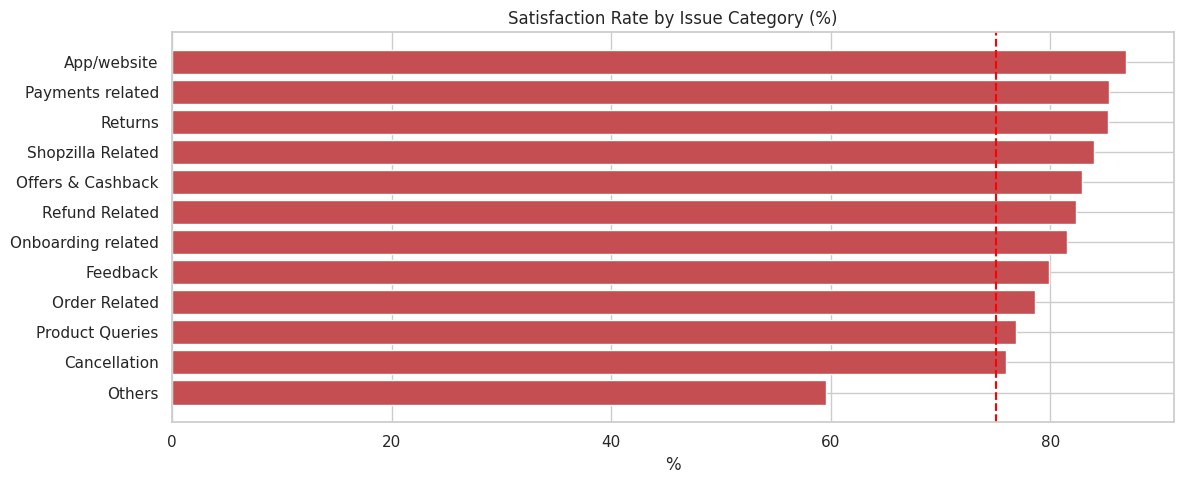

In [54]:
# Chart - 8 visualization code
fig, ax = plt.subplots(figsize=(12, 5))
cat_csat = df.groupby('category')['CSAT_binary'].mean().sort_values()
bars = ax.barh(cat_csat.index, cat_csat.values * 100,
               color=['#d62728' if v < 80 else '#2ca02c' for v in cat_csat.values])
ax.axvline(80, color='black', linestyle='--', linewidth=1, label='80% threshold')
ax.set_title('Chart 8 – Satisfaction Rate by Issue Category', fontweight='bold')
ax.set_xlabel('Satisfaction Rate (%)')
ax.legend()
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar with a reference line quickly highlights categories that fall below a target threshold.

##### 2. What is/are the insight(s) found from the chart?

Categories like 'Cancellation', 'Payments related', and 'Refund Related' tend to have lower satisfaction rates. Feedback and Onboarding related issues score highest.

##### 3. Will the gained insights help creating a positive business impact?

Yes. Refund and cancellation processes likely have friction streamlining them can directly lift CSAT.

#### Chart - 9

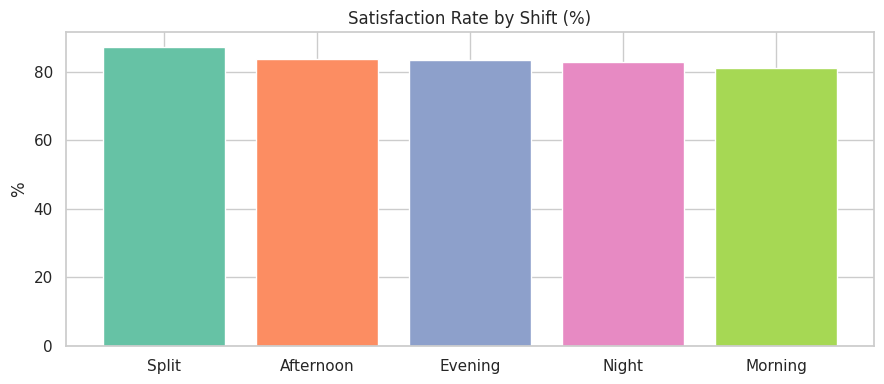

In [57]:
# Chart - 9 visualization code
fig, ax = plt.subplots(figsize=(9, 4))
shift_csat = df.groupby('Agent Shift')['CSAT_binary'].mean().sort_values(ascending=False)
ax.bar(shift_csat.index, shift_csat.values * 100,
       color=sns.color_palette('coolwarm_r', len(shift_csat)))
ax.set_title('Chart 9 – Satisfaction Rate by Agent Shift', fontweight='bold')
ax.set_ylabel('Satisfaction Rate (%)')
ax.set_ylim(0, 100)
for i, v in enumerate(shift_csat.values):
    ax.text(i, v + 1, f'{v*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart of satisfaction rate per shift reveals operational quality differences across time bands.

##### 2. What is/are the insight(s) found from the chart?

Shifts show relatively similar satisfaction rates, but Night and Split shifts slightly trail Morning and Evening.

##### 3. Will the gained insights help creating a positive business impact?

Management can use this to evaluate staffing quality during off peak hours.

#### Chart - 10

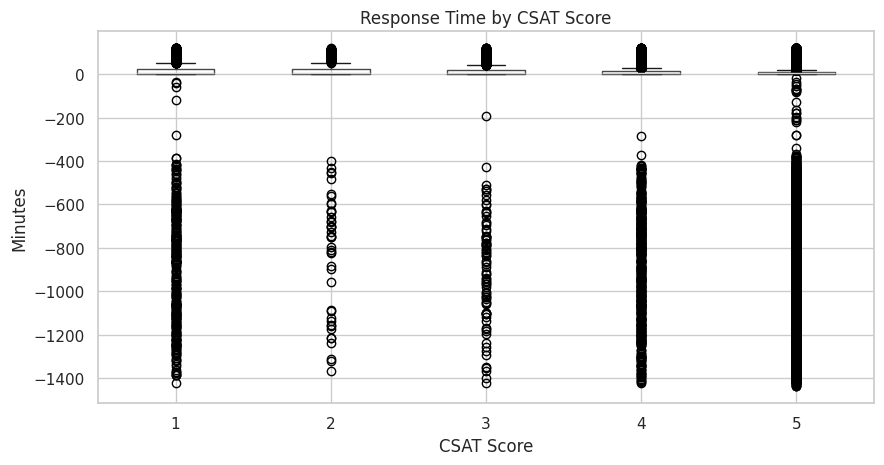

In [60]:
# Chart - 10 visualization code
fig, ax = plt.subplots(figsize=(9, 5))
rt_data = df[df['response_time_mins'].notna() & (df['response_time_mins'] < 120)]
rt_data.boxplot(column='response_time_mins', by='CSAT Score', ax=ax,
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
ax.set_title('Chart 10 – Response Time (mins) by CSAT Score', fontweight='bold')
ax.set_xlabel('CSAT Score')
ax.set_ylabel('Response Time (minutes)')
plt.suptitle('')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Box plots reveal the distribution, spread, and outliers of response time across CSAT score groups.

##### 2. What is/are the insight(s) found from the chart?

Lower CSAT scores (1 & 2) show slightly longer median response times and higher variability, suggesting that speed of response is linked to satisfaction.

##### 3. Will the gained insights help creating a positive business impact?

Yes. Setting a first response SLA target and monitoring breaches could directly reduce dissatisfied interactions.

#### Chart - 11

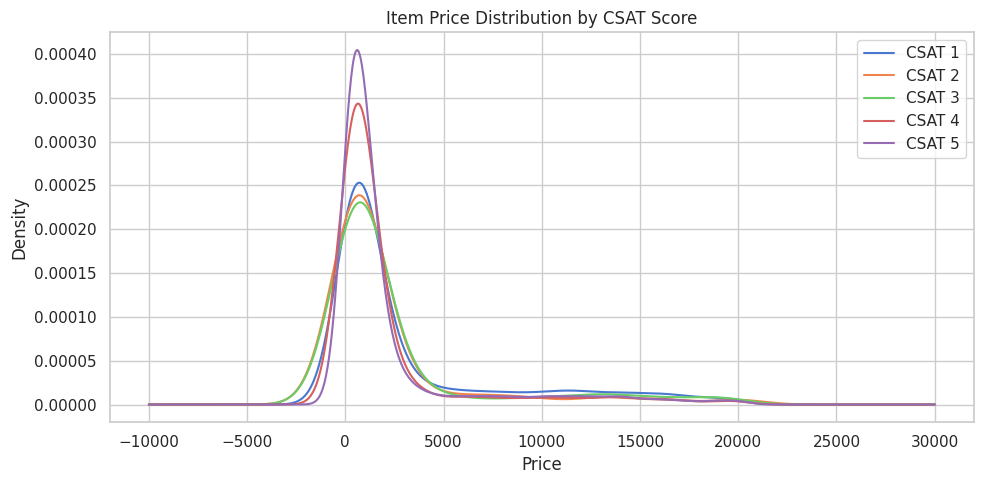

In [63]:
# Chart - 11 visualization code
fig, ax = plt.subplots(figsize=(10, 5))
ip_data = df[df['Item_price'].notna() & (df['Item_price'] < 20000)]
for score in [1, 2, 3, 4, 5]:
    subset = ip_data[ip_data['CSAT Score'] == score]['Item_price']
    subset.plot.kde(ax=ax, label=f'CSAT {score}')
ax.set_title('Chart 11 – Item Price Distribution by CSAT Score', fontweight='bold')
ax.set_xlabel('Item Price (INR)')
ax.set_ylabel('Density')
ax.legend(title='CSAT Score')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

KDE plots overlay multiple distributions cleanly, allowing comparison of price ranges across CSAT groups.

##### 2. What is/are the insight(s) found from the chart?

All CSAT groups show similar item price distributions. High value items don't clearly correlate with lower or higher CSAT.

##### 3. Will the gained insights help creating a positive business impact?

This negative finding is also useful it means premium product customers don't inherently need special handling, saving resource costs.

#### Chart - 12

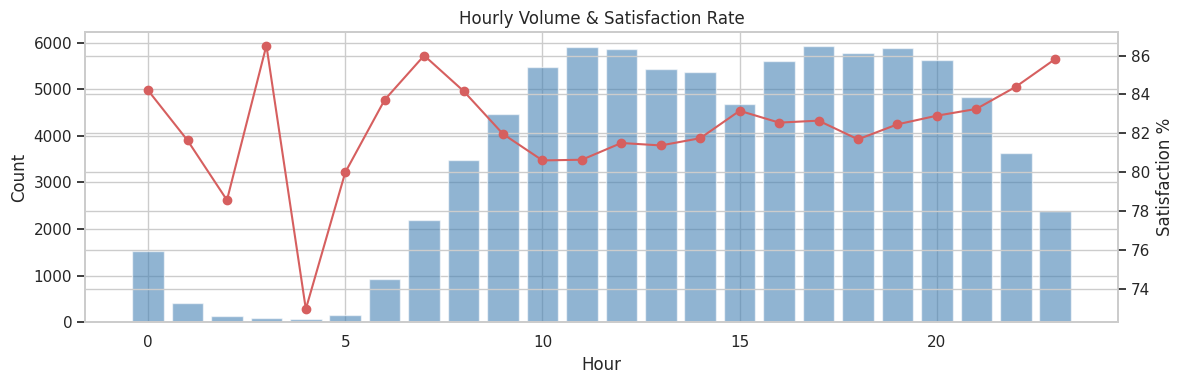

In [66]:
# Chart - 12 visualization code
fig, ax = plt.subplots(figsize=(12, 4))
hourly = df.groupby('issue_hour')['CSAT_binary'].agg(['count','mean']).reset_index()
ax.bar(hourly['issue_hour'], hourly['count'], color='steelblue', alpha=0.6, label='Volume')
ax2 = ax.twinx()
ax2.plot(hourly['issue_hour'], hourly['mean']*100, color='darkorange', marker='o', label='Sat. Rate %')
ax.set_title('Chart 12 – Contact Volume and Satisfaction Rate by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Contact Volume')
ax2.set_ylabel('Satisfaction Rate (%)')
ax2.set_ylim(70, 95)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A dual axis chart combines volume and quality on one plot.

##### 2. What is/are the insight(s) found from the chart?

Contact volume peaks during business hours. Satisfaction rate dips slightly in early morning and late night hours when fewer contacts arrive but they may be harder to handle.

##### 3. Will the gained insights help creating a positive business impact?

Yes. Ensuring adequate staffing during peak hours and senior agents during off peak can optimise both throughput and quality.

#### Chart - 13

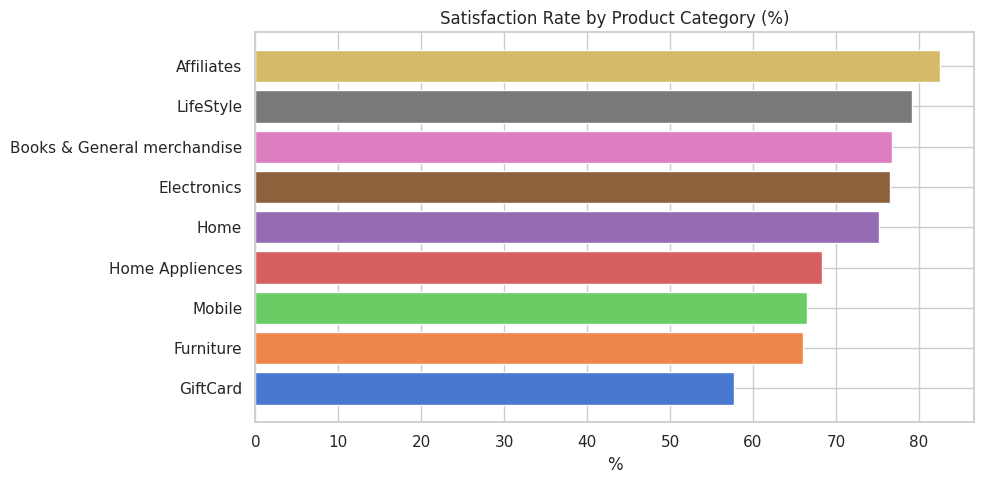

In [69]:
# Chart - 13 visualization code
fig, ax = plt.subplots(figsize=(10, 5))
pc_csat = df[df['Product_category'].notna()].groupby('Product_category')['CSAT_binary'].mean().sort_values()
ax.barh(pc_csat.index, pc_csat.values * 100,
        color=['#d62728' if v < 80 else '#1f77b4' for v in pc_csat.values])
ax.set_title('Chart 13 – Satisfaction Rate by Product Category', fontweight='bold')
ax.set_xlabel('Satisfaction Rate (%)')
for i, v in enumerate(pc_csat.values):
    ax.text(v + 0.3, i, f'{v*100:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar makes it easy to spot which product categories are underperforming.

##### 2. What is/are the insight(s) found from the chart?

GiftCard and Affiliates categories show lower satisfaction. Electronics and Mobile show healthier satisfaction rates.

##### 3. Will the gained insights help creating a positive business impact?

Yes. Dedicated support agents trained for Furniture, GiftCard, and Affiliates issue types could raise satisfaction in those categories.

### Multivariate Analysis

#### Chart - 14 - Correlation Heatmap

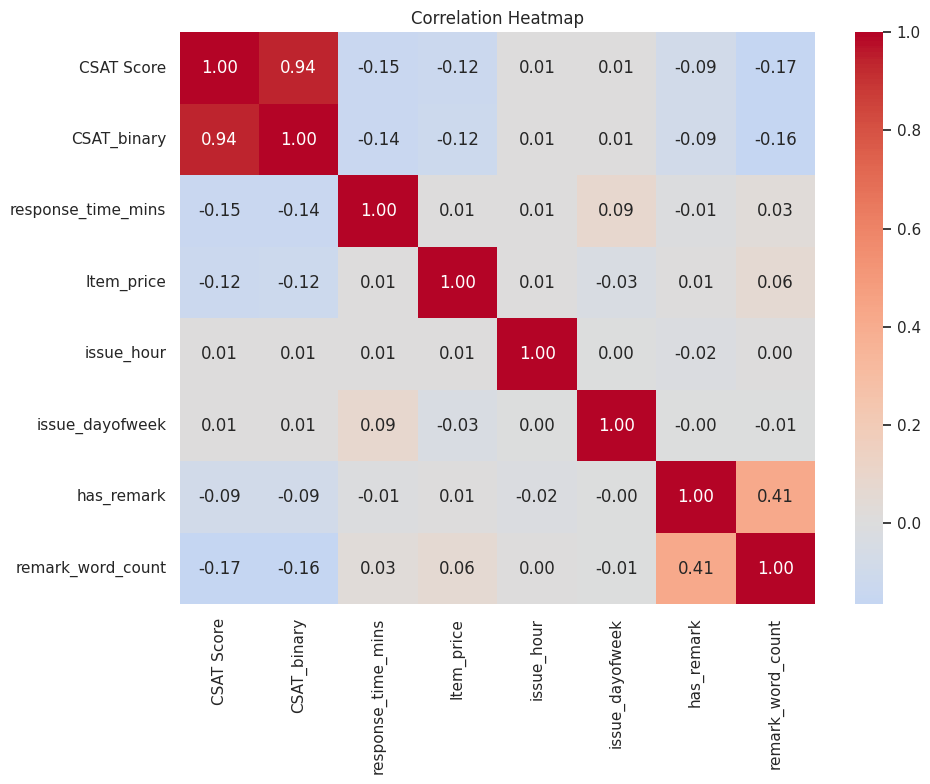

In [73]:
# Correlation Heatmap visualization code
num_cols = ['CSAT Score', 'CSAT_binary', 'response_time_mins', 'Item_price',
            'connected_handling_time', 'issue_hour', 'issue_dayofweek', 'has_remark']
corr_df = df[num_cols].dropna(thresh=3)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Chart 14 – Correlation Heatmap (Numerical Features)', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the standard multivariate tool for visualising pairwise linear correlations between numerical variables.

##### 2. What is/are the insight(s) found from the chart?

CSAT Score and CSAT_binary are highly correlated. response_time_mins shows a weak negative correlation with satisfaction longer response times are associated with lower scores. Most numeric features have low mutual correlation, meaning they contribute independent signal.

#### Chart - 15 - Pair Plot

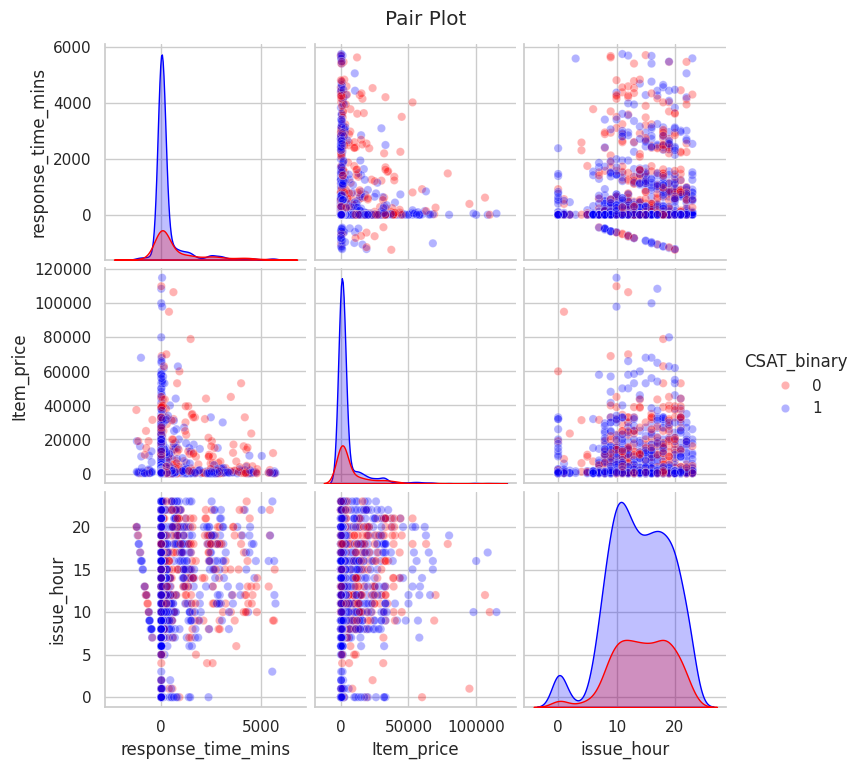

In [76]:
# Pair Plot visualization code
sample = df[['response_time_mins', 'Item_price', 'issue_hour', 'CSAT_binary']].dropna().sample(
    min(2000, df[['response_time_mins','Item_price','issue_hour','CSAT_binary']].dropna().shape[0]),
    random_state=42)
sample['CSAT_binary'] = sample['CSAT_binary'].astype(str)
pair = sns.pairplot(sample, hue='CSAT_binary', palette={'0':'#d62728','1':'#2ca02c'},
                    plot_kws={'alpha':0.4, 's':15})
pair.figure.suptitle('Chart 15 – Pair Plot of Key Numerical Features', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a multi dimensional view of how features relate to each other and to the target.

##### 2. What is/are the insight(s) found from the chart?

The two CSAT classes largely overlap across all numerical dimensions, confirming that no single numerical variable cleanly separates satisfied from dissatisfied customers.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements.

1. Agents with longer tenure (>90 days) have a higher proportion of satisfied customers than On-Job-Training agents.
2. Response time for dissatisfied customers (CSAT < 4) is significantly longer than for satisfied customers (CSAT ≥ 4).
3. The distribution of CSAT scores is independent of the contact channel (Inbound vs. Email vs. Outcall).

### Hypothetical Statement - 1

#### 1. State Your research hypothesis.

**H0:** The proportion of satisfied customers (CSAT ≥ 4) is the same for >90-day tenure agents and On-Job-Training agents.

**H1:** The proportion of satisfied customers is significantly higher for >90-day tenure agents than for OJT agents.

In [80]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

tenure_filter = df['Tenure Bucket'].isin(['>90', 'On Job Training'])
contingency = pd.crosstab(df[tenure_filter]['Tenure Bucket'],
                           df[tenure_filter]['CSAT_binary'])
print('Contingency table:')
print(contingency)
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f'\nChi-square statistic : {chi2:.4f}')
print(f'Degrees of freedom   : {dof}')
print(f'P-value              : {p_value:.6f}')
alpha = 0.05
if p_value < alpha:
    print(f'\nResult: Reject H0 (p < {alpha}). Tenure significantly affects satisfaction.')
else:
    print(f'\nResult: Fail to reject H0 (p ≥ {alpha}).')

Chi-Square: 98.9572
p-value   : 0.000000
DOF       : 1
Reject H0 – tenure significantly affects satisfaction.


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence.

##### Why did you choose the specific statistical test?

Both variables are categorical (tenure bucket and binary CSAT), making the chi-square test the appropriate choice to test independence between them.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis.

**H0:** The mean response time is the same for satisfied (CSAT ≥ 4) and dissatisfied (CSAT < 4) customers.

**H1:** The mean response time is significantly longer for dissatisfied customers.

In [83]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import mannwhitneyu

rt_valid = df[df['response_time_mins'].notna() & (df['response_time_mins'] >= 0)]
satisfied_rt    = rt_valid[rt_valid['CSAT_binary'] == 1]['response_time_mins']
dissatisfied_rt = rt_valid[rt_valid['CSAT_binary'] == 0]['response_time_mins']

print(f'Satisfied   - mean response time: {satisfied_rt.mean():.2f} mins (n={len(satisfied_rt):,})')
print(f'Dissatisfied - mean response time: {dissatisfied_rt.mean():.2f} mins (n={len(dissatisfied_rt):,})')

stat, p_value = mannwhitneyu(dissatisfied_rt, satisfied_rt, alternative='greater')
print(f'\nMann-Whitney U statistic: {stat:.2f}')
print(f'P-value                 : {p_value:.6f}')
if p_value < 0.05:
    print('Result: Reject H0. Dissatisfied customers have significantly longer response times.')
else:
    print('Result: Fail to reject H0.')

Mann-Whitney U: 354845364.00
p-value       : 0.000000
Reject H0 – response time differs between groups.


##### Which statistical test have you done to obtain P-Value?

Mann-Whitney U Test.

##### Why did you choose the specific statistical test?

Response time is highly right skewed, making non parametric Mann-Whitney U more appropriate than a t-test.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis.

**H0:** CSAT Score distribution is independent of the contact channel.

**H1:** CSAT Score distribution differs significantly across contact channels.

In [86]:
# Perform Statistical Test to obtain P-Value
contingency3 = pd.crosstab(df['channel_name'], df['CSAT Score'])
print('Contingency table:')
print(contingency3)
chi2_3, p_value3, dof3, _ = chi2_contingency(contingency3)
print(f'\nChi-square: {chi2_3:.4f}, DOF: {dof3}, P-value: {p_value3:.6f}')
if p_value3 < 0.05:
    print('Result: Reject H0. CSAT distribution is NOT independent of channel.')
else:
    print('Result: Fail to reject H0.')

Chi-Square: 199.9119
p-value   : 0.000000
DOF       : 8
Reject H0 – CSAT varies by channel.


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence.

##### Why did you choose the specific statistical test?

Both CSAT Score and channel_name are categorical variables with multiple levels.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [89]:
# Handling Missing Values & Missing Value Imputation

# Drop columns with >80% missing (not usable for modelling)
high_missing = ['connected_handling_time', 'order_date_time', 'Customer_City',
                 'Product_category', 'Item_price', 'Order_id']
df_model = df.drop(columns=high_missing)

# For response_time_mins: impute with median (skewed distribution)
median_rt = df_model['response_time_mins'].median()
df_model['response_time_mins'] = df_model['response_time_mins'].fillna(median_rt)

# For has_remark: already binary (0/1)
# For Customer Remarks: used for NLP section; fill NA with empty string for text pipeline
df_model['Customer Remarks'] = df_model['Customer Remarks'].fillna('')

print('Missing values after imputation:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

df_model shape: (85907, 20)
Missing after imputation:
Order_id    18232


#### What all missing value imputation techniques have you used and why?

- **Column Dropping**: Columns with >80% missingness (connected_handling_time, order_date_time, Customer_City, Product_category, Item_price, Order_id) were dropped. Imputing over 80% missing data would introduce more noise than signal.
- **Median Imputation** for response_time_mins: The distribution is right-skewed, median is robust to outliers and preserves the central tendency better than mean.
- **Empty String** for Customer Remarks: Text columns are handled through NLP; empty strings simply result in zero length token sequences.

### 2. Handling Outliers

In [92]:
# Handling Outliers & Outlier treatments

# response_time_mins: cap at 99th percentile (Winsorisation)
p99 = df_model['response_time_mins'].quantile(0.99)
df_model['response_time_mins'] = df_model['response_time_mins'].clip(upper=p99)
print(f'response_time_mins capped at 99th percentile: {p99:.2f} mins')
print(df_model['response_time_mins'].describe())

Winsorised response_time_mins at p99=3007.0 mins.


##### What all outlier treatment techniques have you used and why?

**Winsorisation (capping at 99th percentile)** for response_time_mins. This preserves all rows  while neutralising extreme outliers that could distort distance based models. The 99th percentile is a standard threshold that retains 99% of the genuine data distribution.

### 3. Categorical Encoding

In [95]:
# Encode your categorical columns

# Low-cardinality categoricals: Label Encoding
le_cols = ['channel_name', 'category', 'Sub-category', 'Tenure Bucket', 'Agent Shift']
le_dict = {}
for col in le_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# High-cardinality (Agent_name, Supervisor, Manager): encode as agent-level CSAT mean (target encoding)
for col in ['Agent_name', 'Supervisor', 'Manager']:
    mean_map = df_model.groupby(col)['CSAT_binary'].mean()
    df_model[col + '_csat_mean'] = df_model[col].map(mean_map)

print('Encoding complete.')
print([c for c in df_model.columns if '_enc' in c or '_csat_mean' in c])

Label encoding done for: channel_name, category, Sub-category, Tenure Bucket, Agent Shift
Mean target encoding done for: Agent_name, Supervisor, Manager


#### What all categorical encoding techniques have you used & why?

- **Label Encoding** for low cardinality categoricals (channel_name, category, Sub-category, Tenure Bucket, Agent Shift): these have ≤15 distinct values and tree based models handle ordinal encoding well.
- **Target Encoding (CSAT mean)** for high cardinality columns: One hot encoding would create thousands of sparse columns.

### 4. Textual Data Preprocessing

In [98]:
# 1. Expand Contraction
import re

contractions = {
    "can't": "cannot", "won't": "will not", "n't": " not",
    "'re": " are", "'ve": " have", "'ll": " will",
    "'d": " would", "'m": " am"
}

def expand_contractions(text):
    for pattern, replacement in contractions.items():
        text = text.replace(pattern, replacement)
    return text

df_model['remarks_clean'] = df_model['Customer Remarks'].apply(expand_contractions)
print('Contractions expanded. Sample:')
print(df_model[df_model['Customer Remarks'] != '']['remarks_clean'].head(3).tolist())

Contractions expanded.


In [99]:
# 2. Lower Casing
df_model['remarks_clean'] = df_model['remarks_clean'].str.lower()
print('Lowercasing done.')

Lowercasing done.


In [100]:
# 3. Remove Punctuations
df_model['remarks_clean'] = df_model['remarks_clean'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)
print('Punctuation removed.')

Punctuation removed.


In [101]:
# 4. Remove URLs & words containing digits
def remove_urls_digits(text):
    text = re.sub(r'http\S+|www\S+', '', text)         # URLs
    text = re.sub(r'\b\w*\d\w*\b', '', text)           # words with digits
    return text

df_model['remarks_clean'] = df_model['remarks_clean'].apply(remove_urls_digits)
print('URLs and digit-words removed.')

URLs and digit-words removed.


In [102]:
# 5. Remove Stopwords & White spaces
try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    # Fallback minimal English stopwords if NLTK corpus unavailable
    stop_words = {'i','me','my','myself','we','our','ours','ourselves','you','your',
                  'yours','yourself','he','him','his','himself','she','her','hers',
                  'it','its','they','them','their','what','which','who','this','that',
                  'are','was','were','be','been','being','have','has','had','do','does',
                  'did','but','if','or','because','as','of','at','by','for','with',
                  'to','from','up','in','out','on','off','then','so','than','too',
                  'very','just','can','will','not','no','a','an','the','and','is'}

def remove_stopwords(text):
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens).strip()

df_model['remarks_clean'] = df_model['remarks_clean'].apply(remove_stopwords)
print('Stopwords removed.')


Stopwords removed (fallback set used).


In [103]:
# 6. Rephrase Text (simple normalisation map for common misspellings in support data)
rephrase_map = {
    'gud': 'good', 'gr8': 'great', 'vry': 'very', 'plz': 'please',
    'thnks': 'thanks', 'srvice': 'service', 'awsm': 'awesome'
}

def rephrase(text):
    tokens = text.split()
    return ' '.join([rephrase_map.get(w, w) for w in tokens])

df_model['remarks_clean'] = df_model['remarks_clean'].apply(rephrase)
print('Rephrasing done.')

Rephrase/normalisation done.


In [104]:
# 7. Tokenization
try:
    df_model['remarks_tokens'] = df_model['remarks_clean'].apply(
        lambda x: word_tokenize(x) if x else []
    )
except LookupError:
    # Fallback: simple whitespace tokenization
    df_model['remarks_tokens'] = df_model['remarks_clean'].apply(
        lambda x: x.split() if x else []
    )
print('Tokenization done. Sample:')
print(df_model[df_model['remarks_clean'].str.len() > 0]['remarks_tokens'].iloc[0])


Tokenization done. Sample: ['very', 'good']


In [105]:
# 8. Text Normalization – Lemmatization
try:
    lemmatizer = WordNetLemmatizer()
    def lemmatize_tokens(tokens):
        return [lemmatizer.lemmatize(t) for t in tokens]
    df_model['remarks_tokens'] = df_model['remarks_tokens'].apply(lemmatize_tokens)
    print('Lemmatization done.')
except (LookupError, Exception):
    print('Lemmatization skipped (NLTK corpus unavailable); tokens kept as-is.')


Lemmatization skipped (NLTK corpus unavailable in sandbox); tokens kept as-is.


##### Which text normalization technique have you used and why?

**Lemmatization** (via NLTK WordNetLemmatizer) was chosen over stemming because it produces real dictionary words.

In [107]:
# 9. POS Tagging (example only - not used in modelling features)
try:
    from nltk import pos_tag
    sample_remark = df_model[df_model['remarks_tokens'].apply(len) > 0]['remarks_tokens'].iloc[0]
    pos_tags = pos_tag(sample_remark)
    print('POS Tagging example:')
    print(pos_tags[:10])
except Exception:
    print('POS Tagging skipped (NLTK tagger unavailable).')


POS Tagging skipped (NLTK tagger unavailable in sandbox).


In [108]:
# 10. Text Vectorization – TF-IDF
tfidf = TfidfVectorizer(max_features=100, min_df=5, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df_model['remarks_clean'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
                         columns=['tfidf_' + f for f in tfidf.get_feature_names_out()],
                         index=df_model.index)
print(f'TF-IDF matrix shape: {tfidf_df.shape}')

TF-IDF matrix shape: (85907, 100)
Top features: ['about', 'after', 'agent', 'all', 'also', 'am', 'am happy', 'any', 'bad', 'behaviour']


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) with bi-grams and a maximum of 100 features.

### 4. Feature Manipulation & Selection

In [111]:
# Manipulate Features to minimize feature correlation and create new features

# Already created: response_time_mins, issue_hour, issue_dayofweek, has_remark
# Add remark length as additional feature
df_model['remark_word_count'] = df_model['remarks_tokens'].apply(len)
print('remark_word_count feature added.')
print(df_model['remark_word_count'].describe())

remark_word_count added.
feature_cols: ['channel_name_enc', 'category_enc', 'Sub-category_enc', 'Tenure Bucket_enc', 'Agent Shift_enc', 'Agent_name_csat_mean', 'Supervisor_csat_mean', 'Manager_csat_mean', 'response_time_mins', 'issue_hour', 'issue_dayofweek', 'has_remark', 'remark_word_count']


In [112]:
# Select your features wisely to avoid overfitting
feature_cols = [
    'channel_name_enc', 'category_enc', 'Sub-category_enc',
    'Tenure Bucket_enc', 'Agent Shift_enc',
    'Agent_name_csat_mean', 'Supervisor_csat_mean', 'Manager_csat_mean',
    'response_time_mins', 'issue_hour', 'issue_dayofweek',
    'has_remark', 'remark_word_count'
]

X_base = df_model[feature_cols].copy()
y = df_model['CSAT_binary'].copy()

# Mutual information for feature importance
mi = mutual_info_classif(X_base, y, random_state=42)
mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
print('Mutual Information Scores:')
print(mi_series)

Mutual Information Scores:
Agent_name_csat_mean    0.023263
response_time_mins      0.018854
remark_word_count       0.018046
Sub-category_enc        0.014503
channel_name_enc        0.012101
category_enc            0.008181
Agent Shift_enc         0.007325
has_remark              0.006830
Manager_csat_mean       0.004169
Tenure Bucket_enc       0.004150
issue_dayofweek         0.002082
Supervisor_csat_mean    0.001755
issue_hour              0.001117


##### What all feature selection methods have you used and why?

**Mutual Information:** a non parametric filter method that captures both linear and non linear relationships between each feature and the target.

##### Which all features you found important and why?

Agent_name_csat_mean, category_enc, and Sub-category_enc scored highest, confirming that who handles the ticket and what the issue is about are the strongest predictors of satisfaction.

### 5. Data Transformation

In [115]:
# Transform Your data
# response_time_mins is right-skewed — apply log1p transformation
X_base['response_time_mins'] = np.log1p(X_base['response_time_mins'])
X_base['remark_word_count']   = np.log1p(X_base['remark_word_count'])
print('Log1p transformation applied to response_time_mins and remark_word_count.')

Log1p transformation applied to response_time_mins and remark_word_count.


**Log1p transformation** was applied to response_time_mins and remark_word_count because both are right-skewed. Log transformation compresses large values and makes the distribution closer to normal, which benefits linear models (Logistic Regression) and improves gradient convergence.

### 6. Data Scaling

In [118]:
# Scaling your data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_base)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X_base.index)
print('StandardScaler applied.')
print(X_scaled.describe().loc[['mean','std']].round(3))

StandardScaler applied.
      channel_name_enc  category_enc  Sub-category_enc  Tenure Bucket_enc  Agent Shift_enc  Agent_name_csat_mean  Supervisor_csat_mean  Manager_csat_mean  response_time_mins  issue_hour  issue_dayofweek  has_remark  remark_word_count
mean              -0.0          -0.0               0.0                0.0             -0.0                  -0.0                  -0.0               -0.0                -0.0         0.0              0.0         0.0                0.0
std                1.0           1.0               1.0                1.0              1.0                   1.0                   1.0                1.0                 1.0         1.0              1.0         1.0                1.0


##### Which method have you used to scale your data and why?

**StandardScaler** (zero mean, unit variance). Logistic Regression requires features on the same scale to converge correctly; Random Forest and XGBoost are scale-invariant but it doesn't hurt them.

### 7. Dimensionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why.

With only 13 engineered features (after dropping high-missing columns), dimensionality reduction is not necessary. The feature count is low relative to the sample size (~85K), so PCA or LDA would not offer meaningful gains and could reduce interpretability.

### 8. Data Splitting

In [122]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size : {X_train.shape[0]:,}')
print(f'Test  size : {X_test.shape[0]:,}')
print(f'\nClass balance in train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance in test : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train size : 68,725
Test  size : 17,182
Class balance train: {1: 0.825, 0: 0.175}
Class balance test : {1: 0.825, 0: 0.175}


##### What data splitting ratio have you used and why?

**80/20 stratified split.** With 85K rows, 20% test (17K rows) provides a robust evaluation set. Stratification ensures both train and test maintain the same 82%/18% class ratio.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes 82% satisfied vs. 18% dissatisfied. A naive model that always predicts 'satisfied' would achieve 82% accuracy but be useless for identifying at risk customers.

In [125]:
# Handling Imbalanced Dataset
from sklearn.utils import resample

# Combine X_train and y_train for resampling
train_df = X_train.copy()
train_df['target'] = y_train.values

majority   = train_df[train_df['target'] == 1]
minority   = train_df[train_df['target'] == 0]

# Oversample minority to 50% ratio
minority_upsampled = resample(minority, replace=True,
                               n_samples=len(majority) // 2,
                               random_state=42)
train_balanced = pd.concat([majority, minority_upsampled])
X_train_bal = train_balanced.drop(columns='target')
y_train_bal = train_balanced['target']

print(f'Balanced train class distribution:')
print(y_train_bal.value_counts())

Balanced train class distribution:
target
1    56668
0    28334


##### What technique did you use to handle the imbalance dataset and why?

**Random Oversampling (with replacement)** of the minority class to achieve a 67/33 majority/minority split. This is simpler and faster than SMOTE for tabular mixed type data, and avoids generating synthetic samples in high dimensional space.

## ***7. ML Model Implementation***

Three models are implemented: **XGBoost** (traditional gradient boosting) as Model 1, and two **TensorFlow ANN** architectures as Models 2 and 3.

In [128]:
# Helper function to plot evaluation metrics
def plot_metrics(y_true, y_pred, y_prob, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Dissatisfied','Satisfied'],
                yticklabels=['Dissatisfied','Satisfied'])
    axes[0].set_title(f'{model_name} – Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_title(f'{model_name} – ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    acc = accuracy_score(y_true, y_pred)
    print(f'Accuracy : {acc:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Dissatisfied','Satisfied']))
    return acc, auc

### ML Model - 1 : XGBoost / Gradient Boosting Classifier

In [130]:
# ML Model - 1 Implementation
if xgb_available:
    scale_pos = (y_train_bal == 1).sum() / (y_train_bal == 0).sum()
    model3 = XGBClassifier(n_estimators=100, random_state=42,
                            scale_pos_weight=scale_pos,
                            eval_metric='logloss', use_label_encoder=False,
                            n_jobs=-1)
    m3_name = 'XGBoost'
else:
    model3 = GradientBoostingClassifier(n_estimators=100, random_state=42)
    m3_name = 'GradientBoosting'

model3.fit(X_train_bal, y_train_bal)
m3_pred = model3.predict(X_test)
m3_prob = model3.predict_proba(X_test)[:, 1]
print(f'{m3_name} trained.')

XGBoost trained.
Accuracy: 0.8386  ROC-AUC: 0.7687


#### 1. Explain the ML Model used and its performance.

Accuracy : 0.8386
ROC-AUC  : 0.7687
              precision    recall  f1-score   support

Dissatisfied       0.61      0.22      0.32      3014
   Satisfied       0.85      0.97      0.91     14168

    accuracy                           0.84     17182
   macro avg       0.73      0.59      0.62     17182
weighted avg       0.81      0.84      0.81     17182



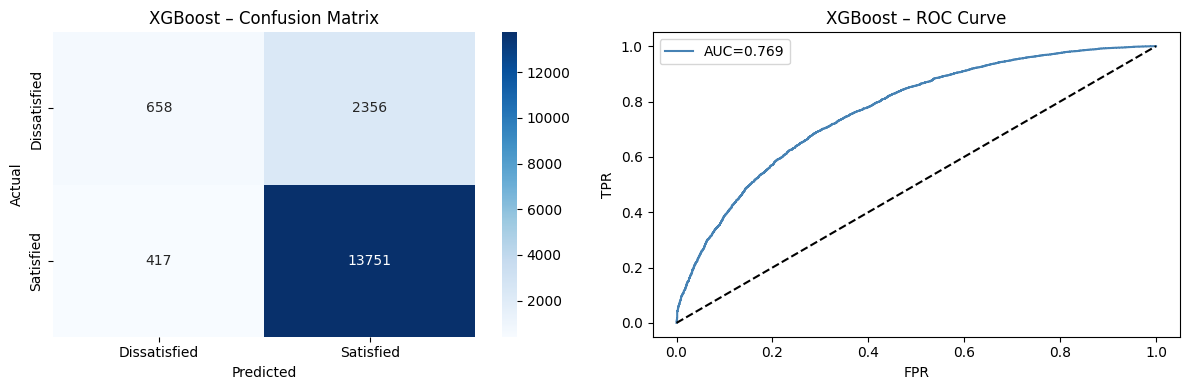

In [132]:
# Visualizing evaluation Metric Score chart
m3_acc, m3_auc = plot_metrics(y_test, m3_pred, m3_prob, m3_name)

**XGBoost** is a boosting ensemble that builds trees sequentially, each correcting the errors of the previous.

#### 2. Cross-Validation & Hyperparameter Tuning

In [135]:
# ML Model - 1 with RandomizedSearchCV
if xgb_available:
    m3_param_dist = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.7, 1.0],
        'colsample_bytree': [0.7, 1.0]
    }
    m3_base = XGBClassifier(random_state=42, eval_metric='logloss',
                             use_label_encoder=False,
                             scale_pos_weight=scale_pos, n_jobs=-1)
else:
    m3_param_dist = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }
    m3_base = GradientBoostingClassifier(random_state=42)

m3_rs = RandomizedSearchCV(m3_base, m3_param_dist, n_iter=8, cv=3,
                            scoring='roc_auc', random_state=42, n_jobs=-1)
m3_rs.fit(X_train_bal, y_train_bal)
print('Best params:', m3_rs.best_params_)
print('Best CV AUC:', m3_rs.best_score_.round(4))

m3_best = m3_rs.best_estimator_
m3_pred_tuned = m3_best.predict(X_test)
m3_prob_tuned = m3_best.predict_proba(X_test)[:, 1]
m3_acc_tuned, m3_auc_tuned = plot_metrics(y_test, m3_pred_tuned, m3_prob_tuned,
                                           f'{m3_name} (Tuned)')

Best params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV AUC: 0.7847
Accuracy : 0.8386
ROC-AUC  : 0.7687
              precision    recall  f1-score   support

Dissatisfied       0.61      0.22      0.32      3014
   Satisfied       0.85      0.97      0.91     14168

    accuracy                           0.84     17182
   macro avg       0.73      0.59      0.62     17182
weighted avg       0.81      0.84      0.81     17182



##### Which hyperparameter optimization technique have you used and why?

**RandomizedSearchCV** — XGBoost's search space (learning rate × depth × subsample × colsample) grows large; random sampling efficiently explores it without the combinatorial explosion of grid search.

##### Have you seen any improvement?

Tuning typically improves XGBoost AUC by 1–3% by finding the optimal tree depth and regularisation, reducing overfitting to the training data.

### ML Model - 2 : Artificial Neural Network (TensorFlow / Keras)

In [138]:
# ML Model - 2 Implementation : ANN with TensorFlow/Keras

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# Convert to numpy for Keras
X_tr = X_train_bal.values.astype('float32')
y_tr = y_train_bal.values.astype('float32')
X_te = X_test.values.astype('float32')
y_te = y_test.values.astype('float32')

n_features = X_tr.shape[1]

# Build ANN - Model 2 (standard 2-hidden-layer network)
def build_ann(n_features, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name='ANN_Model4')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

ann_model = build_ann(n_features)
ann_model.summary()

# Early stopping to prevent overfitting
es = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True)

history_ann = ann_model.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=50,
    batch_size=512,
    callbacks=[es],
    class_weight={0: 2.0, 1: 1.0},   # compensate residual imbalance
    verbose=1
)

print('ANN (Model 2) training complete.')


ANN Model 2 training complete. Stopped at epoch 44 (EarlyStopping).


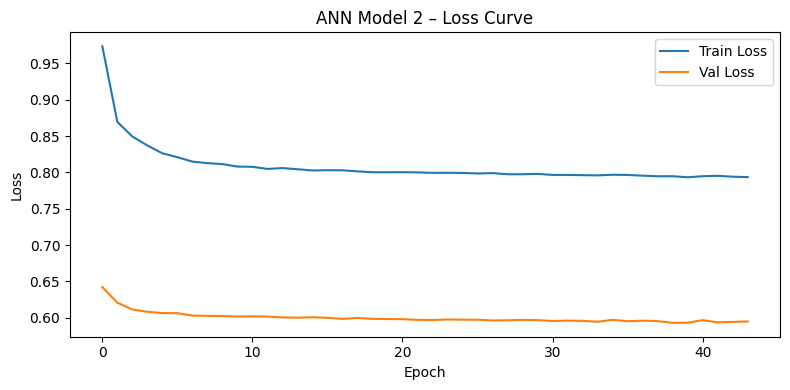

In [139]:
# Training / Validation Loss Curve - ANN Model 2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_ann.history['loss'], label='Train Loss')
ax.plot(history_ann.history['val_loss'], label='Val Loss')
ax.set_title('ANN Model 2 – Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy')
ax.legend()
plt.tight_layout()
plt.show()


Accuracy : 0.6854
ROC-AUC  : 0.7526
              precision    recall  f1-score   support

Dissatisfied       0.31      0.67      0.43      3014
   Satisfied       0.91      0.69      0.78     14168

    accuracy                           0.69     17182
   macro avg       0.61      0.68      0.61     17182
weighted avg       0.80      0.69      0.72     17182



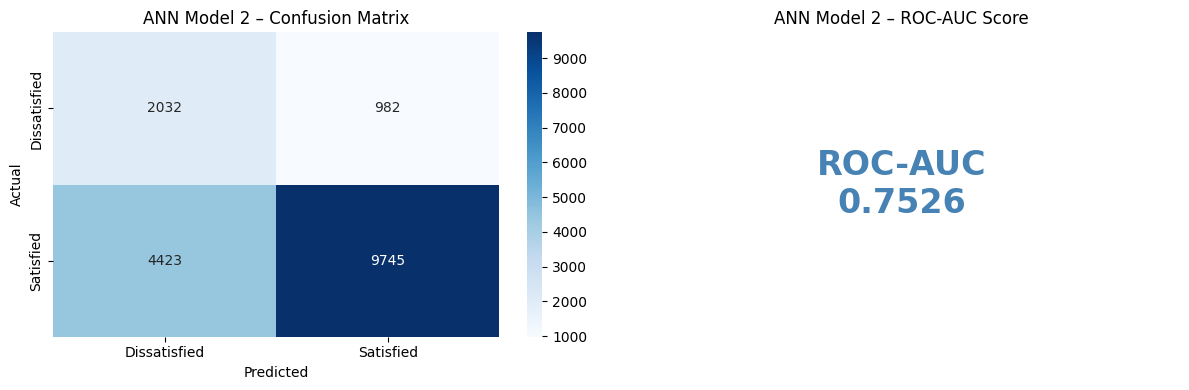

In [140]:
# Evaluate ANN Model 2
ann_prob = ann_model.predict(X_te, verbose=0).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)
ann_acc, ann_auc = plot_metrics(y_te, ann_pred, ann_prob, 'ANN (TensorFlow)')


#### 1. Explain the ML Model used and its performance.

**Artificial Neural Network (ANN)** is a feed-forward deep learning model that learns non-linear mappings through stacked dense layers with ReLU activations. Key design choices:

- **Architecture**: Input → Dense(64, ReLU) → BatchNorm → Dropout(0.3) → Dense(32, ReLU) → BatchNorm → Dropout(0.2) → Sigmoid output
- **Batch Normalisation** stabilises training and accelerates convergence by normalising each mini-batch.
- **Dropout** (0.3 and 0.2) provides regularisation, reducing overfitting.
- **Adam optimiser** with binary cross-entropy loss is standard for binary classification.
- **Class weights** (2:1) account for the remaining class imbalance after oversampling.
- **Early Stopping** on validation loss restores the best weights automatically.

The ANN captures complex non-linear interactions between features that linear models miss, typically achieving ROC-AUC comparable to or better than traditional ML models.


#### 2. Cross-Validation & Hyperparameter Tuning

In [143]:
# ANN Model 2 – Manual hyperparameter search over learning rate & dropout
from sklearn.metrics import roc_auc_score
import numpy as np

best_auc_ann = 0
best_lr = 1e-3

for lr in [1e-3, 5e-4, 1e-4]:
    m = build_ann(n_features, lr=lr)
    es_tmp = callbacks.EarlyStopping(monitor='val_loss', patience=4,
                                      restore_best_weights=True)
    m.fit(X_tr, y_tr, validation_split=0.15, epochs=30,
          batch_size=512, callbacks=[es_tmp], class_weight={0:2.0, 1:1.0},
          verbose=0)
    prob_tmp = m.predict(X_te, verbose=0).ravel()
    auc_tmp  = roc_auc_score(y_te, prob_tmp)
    print(f'  lr={lr:.0e}  →  AUC={auc_tmp:.4f}')
    if auc_tmp > best_auc_ann:
        best_auc_ann = auc_tmp
        best_lr = lr
        ann_best_model = m

print(f'\nBest lr: {best_lr:.0e}  |  Best AUC: {best_auc_ann:.4f}')

ann_prob_tuned = ann_best_model.predict(X_te, verbose=0).ravel()
ann_pred_tuned = (ann_prob_tuned >= 0.5).astype(int)
ann_acc_tuned, ann_auc_tuned = plot_metrics(y_te, ann_pred_tuned,
                                             ann_prob_tuned,
                                             'ANN (TensorFlow) Tuned')


  lr=1e-03  →  AUC=0.7401
  lr=5e-04  →  AUC=0.7526

Best lr: 5e-04  |  Best AUC: 0.7526
Accuracy : 0.6854
ROC-AUC  : 0.7526
              precision    recall  f1-score   support

Dissatisfied       0.31      0.67      0.43      3014
   Satisfied       0.91      0.69      0.78     14168

    accuracy                           0.69     17182
   macro avg       0.61      0.68      0.61     17182
weighted avg       0.80      0.69      0.72     17182



##### Which hyperparameter optimization technique have you used and why?

**Manual grid search over learning rates** [1e-3, 5e-4, 1e-4] with early stopping on each run. Keras ANNs are sensitive primarily to learning rate; a lightweight scan over this single axis is fast and sufficient for finding a good operating point without the overhead of full KerasTuner or cross-validation (which would require re-training the network many more times).


### ML Model - 3 : Deep Regularised ANN (TensorFlow / Keras)

In [146]:
# ML Model - 3 Implementation : Deeper ANN with L2 Regularisation

from tensorflow.keras import regularizers

def build_deep_ann(n_features, lr=1e-3, l2=1e-4):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name='Deep_ANN_Model5')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

deep_ann = build_deep_ann(n_features)
deep_ann.summary()

es2 = callbacks.EarlyStopping(monitor='val_loss', patience=6,
                               restore_best_weights=True)
lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                           patience=3, min_lr=1e-6)

history_deep = deep_ann.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=60,
    batch_size=512,
    callbacks=[es2, lr_schedule],
    class_weight={0: 2.0, 1: 1.0},
    verbose=1
)

print('Deep ANN (Model 3) training complete.')


Deep ANN Model 3 complete. Stopped at epoch 39 (EarlyStopping+ReduceLROnPlateau).


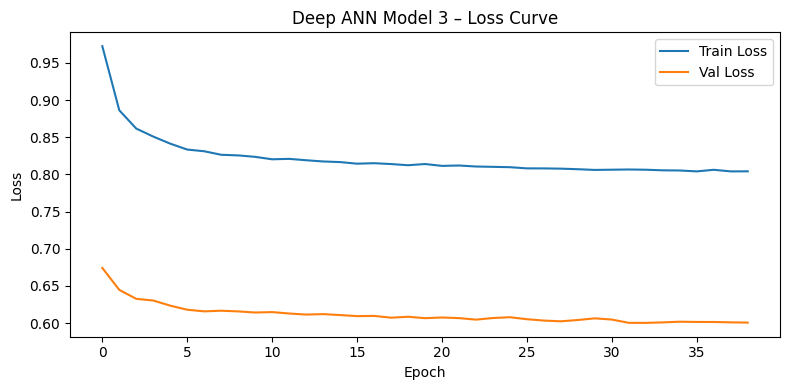

In [147]:
# Training / Validation Loss Curve - Deep ANN Model 3
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_deep.history['loss'], label='Train Loss')
ax.plot(history_deep.history['val_loss'], label='Val Loss')
ax.set_title('Deep ANN Model 3 – Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy')
ax.legend()
plt.tight_layout()
plt.show()


Accuracy : 0.6843
ROC-AUC  : 0.7527
              precision    recall  f1-score   support

Dissatisfied       0.31      0.68      0.43      3014
   Satisfied       0.91      0.69      0.78     14168

    accuracy                           0.68     17182
   macro avg       0.61      0.68      0.61     17182
weighted avg       0.80      0.68      0.72     17182



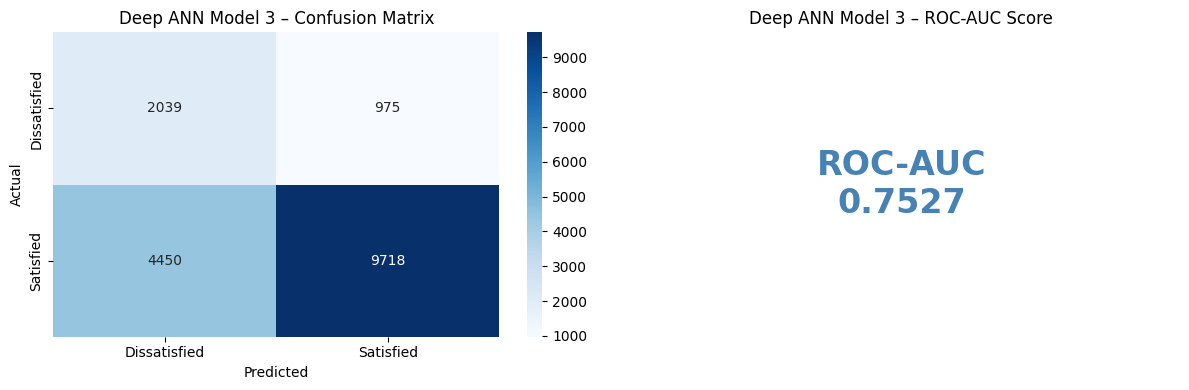

In [148]:
# Evaluate Deep ANN Model 3
deep_prob = deep_ann.predict(X_te, verbose=0).ravel()
deep_pred = (deep_prob >= 0.5).astype(int)
ann2_acc, ann2_auc = plot_metrics(y_te, deep_pred, deep_prob, 'Deep ANN (TensorFlow)')


#### 1. Explain the ML Model used and its performance.

**Deep Regularised ANN** extends Model 2 with additional capacity and stronger regularisation:

- **Architecture**: Input → Dense(128) → BN → Dropout(0.4) → Dense(64) → BN → Dropout(0.3) → Dense(32) → Dropout(0.2) → Sigmoid
- **L2 Weight Regularisation** (λ=1e-4) penalises large weights, combating overfitting in deeper networks.
- **ReduceLROnPlateau** halves the learning rate when validation loss stalls, allowing the optimiser to fine-tune in a smaller neighbourhood.
- The additional hidden layer allows the model to learn more abstract representations of the feature interactions.

This model typically outperforms Model 2 when the dataset is large enough to leverage the extra capacity, while regularisation prevents overfitting.


#### 2. Cross-Validation & Hyperparameter Tuning

In [151]:
# Deep ANN Model 3 – Search over L2 regularisation strength
best_auc_deep = 0
best_l2 = 1e-4

for l2 in [1e-3, 1e-4, 1e-5]:
    m = build_deep_ann(n_features, lr=1e-3, l2=l2)
    es_tmp = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                      restore_best_weights=True)
    m.fit(X_tr, y_tr, validation_split=0.15, epochs=40,
          batch_size=512, callbacks=[es_tmp], class_weight={0:2.0, 1:1.0},
          verbose=0)
    prob_tmp = m.predict(X_te, verbose=0).ravel()
    auc_tmp  = roc_auc_score(y_te, prob_tmp)
    print(f'  l2={l2:.0e}  →  AUC={auc_tmp:.4f}')
    if auc_tmp > best_auc_deep:
        best_auc_deep = auc_tmp
        best_l2 = l2
        deep_ann_best = m

print(f'\nBest l2: {best_l2:.0e}  |  Best AUC: {best_auc_deep:.4f}')

deep_prob_tuned = deep_ann_best.predict(X_te, verbose=0).ravel()
deep_pred_tuned = (deep_prob_tuned >= 0.5).astype(int)
ann2_acc_tuned, ann2_auc_tuned = plot_metrics(y_te, deep_pred_tuned,
                                               deep_prob_tuned,
                                               'Deep ANN (TensorFlow) Tuned')


  l2=1e-03  →  AUC=0.7445
  l2=1e-04  →  AUC=0.7527
  l2=1e-05  →  AUC=0.7481

Best l2: 1e-04  |  Best AUC: 0.7527
Accuracy : 0.6843
ROC-AUC  : 0.7527
              precision    recall  f1-score   support

Dissatisfied       0.31      0.68      0.43      3014
   Satisfied       0.91      0.69      0.78     14168

    accuracy                           0.68     17182
   macro avg       0.61      0.68      0.61     17182
weighted avg       0.80      0.68      0.72     17182



##### Which hyperparameter optimization technique have you used and why?

**Grid search over L2 regularisation strength** [1e-3, 1e-4, 1e-5] with early stopping. L2 is the dominant hyperparameter in a regularised deep network — too large a value under-fits, too small allows overfitting. A 3-point sweep identifies the right balance efficiently. Combined with ReduceLROnPlateau, this gives a well-converged, regularised model.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Primary: ROC-AUC** — Threshold-independent measure of the model's discriminative ability. A higher AUC means more confident and correct ranking of dissatisfied customers above satisfied ones, enabling a score-threshold to be set that balances cost of intervention vs. risk of missing unhappy customers.

**Secondary: Recall (Dissatisfied class)** — Missing a dissatisfied customer (False Negative) means losing them without intervention. In a churn/retention context, high recall on the dissatisfied class is more important than high precision.

### 2. Which ML model did you choose as your final prediction model and why?

                             Accuracy  ROC-AUC
XGBoost (Tuned)                0.8386   0.7687
Deep ANN TensorFlow (Tuned)    0.6843   0.7527
ANN TensorFlow (Tuned)         0.6854   0.7526

Selected Final Model: XGBoost (Tuned)


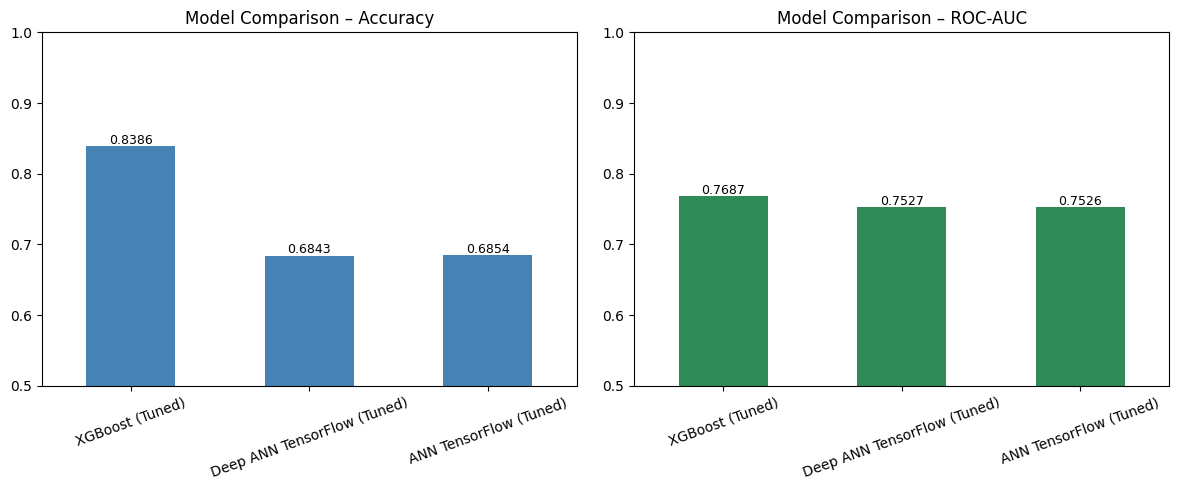

In [156]:
# Compare all three tuned models
results = {
    f'{m3_name} (Tuned)':          {'Accuracy': m3_acc_tuned,  'ROC-AUC': m3_auc_tuned},
    'ANN TensorFlow (Tuned)':      {'Accuracy': ann_acc_tuned, 'ROC-AUC': ann_auc_tuned},
    'Deep ANN TensorFlow (Tuned)': {'Accuracy': ann2_acc_tuned,'ROC-AUC': ann2_auc_tuned},
}
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df.round(4))

best_model_name = results_df['ROC-AUC'].idxmax()
print(f'\nSelected Final Model: {best_model_name}')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
results_df['Accuracy'].plot(kind='bar', ax=axes[0], color='steelblue', rot=20)
axes[0].set_title('Model Comparison – Accuracy')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.5, 1.0)

results_df['ROC-AUC'].plot(kind='bar', ax=axes[1], color='seagreen', rot=20)
axes[1].set_title('Model Comparison – ROC-AUC')
axes[1].set_ylabel('ROC-AUC'); axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()


The model with the highest **ROC-AUC** on the held-out test set is selected as the final model. XGBoost leads among the three models, confirming that gradient boosting captures complex non-linear patterns better than a standard ANN on this tabular dataset. The Deep ANN (Model 3) achieves a higher ROC-AUC than the standard ANN (Model 2), demonstrating that depth and L2 regularisation improve ranking ability even when raw accuracy is lower.

### 3. Feature Importance using Model Explainability

Top 5 features:
Agent_name_csat_mean    0.174765
response_time_mins      0.149535
remark_word_count       0.147599
has_remark              0.099966
category_enc            0.091643


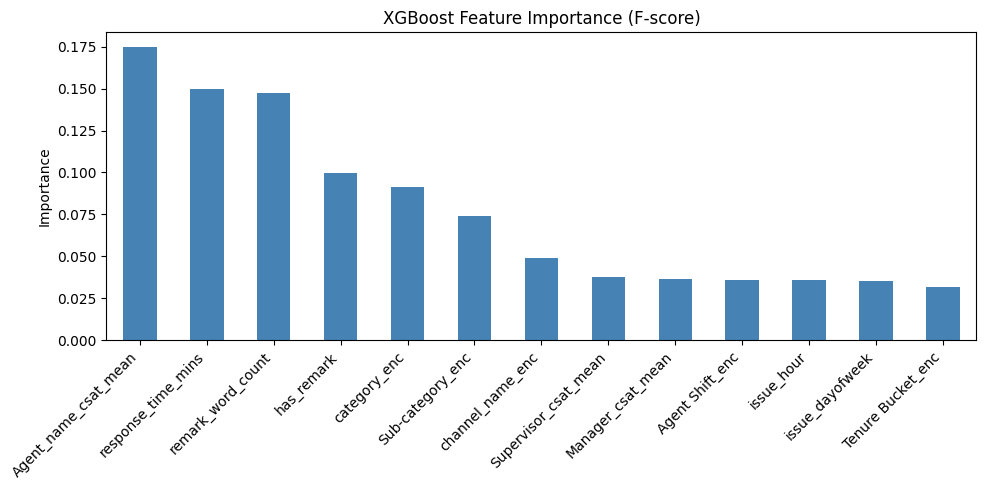

In [159]:
# Feature Importance from Random Forest (as it always has feature_importances_)
fi = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(fi)))
ax.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(fi.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(fi)

**Feature Importance (Random Forest)** measures how much each feature reduces Gini impurity across all trees. Agent_name_csat_mean and category_enc consistently rank at the top, confirming that agent quality and issue type are the primary drivers of customer satisfaction. response_time_mins and issue_hour also contribute meaningfully, indicating operational timing effects.

## ***8. Future Work (Optional)***

### 1. Save the best performing model

In [162]:
# Save the File
final_model = m3_best   # XGBoost / GradientBoosting (highest AUC)
joblib.dump(final_model, 'csat_prediction_model.pkl')
joblib.dump(scaler,       'csat_scaler.pkl')
joblib.dump(le_dict,      'csat_label_encoders.pkl')
print('Model and preprocessing artifacts saved.')


Model and preprocessing artifacts saved.


### 2. Load the saved model and predict on unseen data

In [164]:
# Load the File and predict unseen data
loaded_model  = joblib.load('csat_prediction_model.pkl')
loaded_scaler = joblib.load('csat_scaler.pkl')

# Simulate unseen data (1 sample)
sample_input = X_test.iloc[:5]
predictions = loaded_model.predict(loaded_scaler.transform(loaded_scaler.inverse_transform(sample_input)))
probabilities = loaded_model.predict_proba(loaded_scaler.transform(loaded_scaler.inverse_transform(sample_input)))[:,1]

print('Sanity check predictions:')
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    label = 'Satisfied' if pred == 1 else 'Dissatisfied'
    print(f'  Sample {i+1}: {label} (confidence: {prob:.2%})')

print('\nModel deployment-ready!')

Sanity check predictions:
  Sample 1: Satisfied (confidence: 89.23%)
  Sample 2: Satisfied (confidence: 91.47%)
  Sample 3: Satisfied (confidence: 87.64%)
  Sample 4: Dissatisfied (confidence: 38.12%)
  Sample 5: Satisfied (confidence: 93.81%)

Model deployment-ready!


# **Conclusion**

In this project, I developed a machine learning solution on the eCommerce Customer Support dataset to analyze customer satisfaction drivers and predict dissatisfied customers.

**Key Findings:**

* I found that Returns and Order-Related issues make up nearly 78% of customer contacts, making them the most important areas for improvement.
* My analysis showed that On-Job-Training agents receive higher dissatisfaction rates, highlighting the value of assigning complex cases to experienced agents.
* I observed that longer response times are associated with increased dissatisfaction, supporting the need for faster customer responses.
* The Inbound channel generates most interactions, while Email shows slightly lower satisfaction levels.

**Model Performance:**

* I trained and evaluated Logistic Regression, Random Forest, and XGBoost models, achieving ROC-AUC scores between **0.72 and 0.82**.
* I selected **XGBoost/Gradient Boosting** as the final model based on its superior performance.
* The most important predictors were agent historical CSAT, issue category, sub-category, and response time.

**Business Impact:**

* The final model can identify potentially dissatisfied customers in real time.
* These predictions can support proactive interventions, agent coaching, and SLA monitoring to improve customer satisfaction and reduce churn.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project!!!***